# VLM OCR Supervised Fine-Tuning

Following [here](https://huggingface.co/learn/cookbook/en/fine_tuning_vlm_trl), but making some changes with regards to my use case.


Comments:

- A little concerned that the VLM might just be memorizing the individuals because the train/test set might be leaking (i.e. if came from the same game)
    - Might need to some stratified sampling or test on another labeled jersey dataset
    - Basketball jersey dataset [here](https://universe.roboflow.com/roboflow-jvuqo/basketball-jersey-numbers-ocr), the only issue is it is cropped so might not be an actual good representation of how it will perform in prod

In [55]:
# colab things
from google.colab import drive
drive.mount('/content/drive')

# change working dir
%cd /content/drive/MyDrive/nba2nba/notebooks

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/nba2nba/notebooks


In [56]:
!unzip "/content/drive/MyDrive/nba2nba/data/.cache/nfl_jersey_numbers.zip" -d "/content"

Archive:  /content/drive/MyDrive/nba2nba/data/.cache/nfl_jersey_numbers.zip
replace /content/train_player_numbers.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## Installs + Imports

In [57]:
!pip install -U -q git+https://github.com/huggingface/trl.git bitsandbytes peft qwen-vl-utils trackio

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [58]:
# !pip install flash-attn --no-build-isolation

In [59]:
import os
import gc
import time
# import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import trackio
from transformers import Qwen3VLForConditionalGeneration, Qwen3VLProcessor, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer
from qwen_vl_utils import process_vision_info
from datasets import load_dataset, Image, Dataset

from tqdm.notebook import tqdm

jersey_path = "/content"
SEED = 13

## Dataset Formatting

In [60]:
system_message = """You are a Vision Language Model specialized in determining the number on a basketball player's jersey.
Your task is to analyze the provided in-game image and respond to queries with the jersey number.
If there are multiple jerseys, only respond with the one at the center of the frame that you are most confident in.
If there are no jersey numbers, respond with a '-1'.
Do not return any other information other than the most accurate jersey number.
Do not return any other text other than the number.
"""

In [61]:
# format into message format for llms
def format_data(sample):
    return {
        "images": [sample["image"]],
        "messages": [
            # system context
            {
                "role": "system",
                "content": [
                    {
                        "type": "text",
                        "text": system_message
                    }
                ]
            },
            # user query
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": sample["image"]
                    },
                    {
                        "type": "text",
                        "text": sample["query"]
                    }
                ]
            },
            # llm role
            {
                "role": "assistant",
                "content": [
                    {
                        "type": "text",
                        "text": sample["label"]
                    }
                ]
            }
        ],
    }

In [62]:
# read in data (need to use pandas since polars has pyarrow large-string error)
df = pd.read_csv(os.path.join(jersey_path, "train_player_numbers.csv"))
df["image"] = df["filepath"].apply(lambda x: os.path.join(jersey_path, x))
df["label"] = df["label"].astype(str)
df["query"] = "What is the jersey number of this player?"
df = df[["image", "label", "query"]]
df.head()

,image,label,query
0,/content/train_player_numbers/58000_001306_Sid...,84,What is the jersey number of this player?
1,/content/train_player_numbers/58095_004022_End...,24,What is the jersey number of this player?
2,/content/train_player_numbers/58094_002819_Sid...,83,What is the jersey number of this player?
3,/content/train_player_numbers/57594_000923_Sid...,23,What is the jersey number of this player?
4,/content/train_player_numbers/57680_003470_End...,72,What is the jersey number of this player?


In [63]:
# create dataset
dataset = Dataset.from_pandas(df.sample(n=5000))
dataset = dataset.cast_column("image", Image(decode=True))

# train/val/test splits
train_valtest = dataset.train_test_split(test_size=0.1, seed=SEED)
val_test = train_valtest["test"].train_test_split(test_size=0.5, seed=SEED)
train_dataset, val_dataset, test_dataset = train_valtest["train"], val_test["train"], val_test["test"]

# format datasets into lists
train_dataset = [format_data(sample) for sample in tqdm(train_dataset)]
val_dataset = [format_data(sample) for sample in tqdm(val_dataset)]
test_dataset = [format_data(sample) for sample in tqdm(test_dataset)]

# below doesn't work with PIL images, maybe try filepaths?
# train_dataset = train_dataset.map(format_data, num_proc=4)
# val_dataset = val_dataset.map(format_data, num_proc=4)
# test_dataset = test_dataset.map(format_data, num_proc=4)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

  0%|          | 0/4500 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

Train size: 4500
Val size: 250
Test size: 250


In [64]:
train_dataset[10]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64>],
 'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': "You are a Vision Language Model specialized in determining the number on a basketball player's jersey.\nYour task is to analyze the provided in-game image and respond to queries with the jersey number.\nIf there are multiple jerseys, only respond with the one at the center of the frame that you are most confident in.\nIf there are no jersey numbers, respond with a '-1'.\nDo not return any other information other than the most accurate jersey number.\nDo not return any other text other than the number.\n"}]},
  {'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64>},
    {'type': 'text', 'text': 'What is the jersey number of this player?'}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': '90'}]}]}

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64 at 0x79F94D1D9070>], 'messages': [{'role': 'system', 'content': [{'type': 'text', 'text': "You are a Vision Language Model specialized in determining the number on a basketball player's jersey.\nYour task is to analyze the provided in-game image and respond to queries with the jersey number.\nIf there are multiple jerseys, only respond with the one at the center of the frame that you are most confident in.\nIf there are no jersey numbers, respond with a '-1'.\nDo not return any other information other than the most accurate jersey number.\nDo not return any other text other than the number.\n"}]}, {'role': 'user', 'content': [{'type': 'image', 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64 at 0x79F94D1D9070>}, {'type': 'text', 'text': 'What is the jersey number of this player?'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': '90'}]}]}
[{'role': 'system', 'content': [{'type': 'text

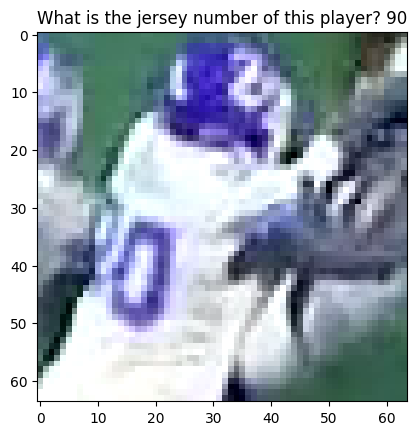

In [65]:
example = train_dataset[10]
print(example)
print(example["messages"])
plt.imshow(example["messages"][1]["content"][0]['image'])
plt.title(f"{example["messages"][1]["content"][1]["text"]} {example["messages"][2]["content"][0]['text']}")
plt.show()


## Qwen3-VL

### Loading the VLM

In [66]:
# choose model
model_id = "Qwen/Qwen3-VL-4B-Instruct"

# load Qwen3VL
model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    dtype=torch.bfloat16
)

processor = Qwen3VLProcessor.from_pretrained(model_id)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [67]:
# perform inference given an example
def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):

    # build LLM conversational template
    text_input = processor.apply_chat_template(
        sample['messages'],
        tokenize=False,
        add_generation_prompt=True
    )

    # qwen image/video path extraction and load tensors
    image_inputs, _ = process_vision_info(sample['messages'])

    # qwen autoprocessor
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)

    # generation
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # remove input tokens
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    # token decoder
    output_text = processor.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]  # Return the first decoded output text

### Testing VLM Base OCR

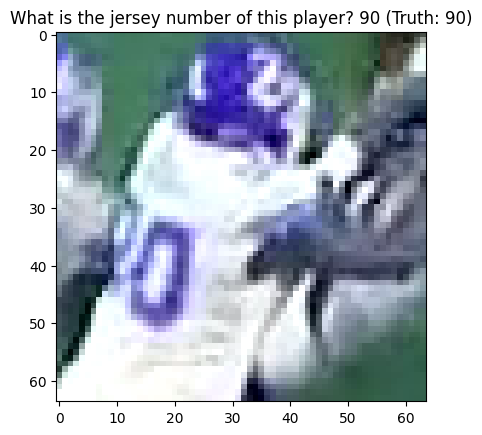

In [68]:
# viz example prediction
example = train_dataset[10]
output = generate_text_from_sample(model, processor, example)
plt.imshow(example["messages"][1]["content"][0]['image'])
plt.title(f"{example["messages"][1]["content"][1]["text"]} {output} (Truth: {example["messages"][2]["content"][0]['text']})")
plt.show()


In [69]:
def clear_memory():
    # Delete variables if they exist in the current global scope
    if 'inputs' in globals(): del globals()['inputs']
    if 'model' in globals(): del globals()['model']
    if 'processor' in globals(): del globals()['processor']
    if 'trainer' in globals(): del globals()['trainer']
    if 'bnb_config' in globals(): del globals()['bnb_config']
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

clear_memory()

GPU allocated memory: 0.02 GB
GPU reserved memory: 4.15 GB


## TRL Fine-Tuning

### Quantization

Overview of quantization [here](https://huggingface.co/blog/merve/quantization).

In [70]:
# nf4 with double quantization (QLoRA config)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# quantize model
model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    dtype=torch.bfloat16,
    quantization_config=bnb_config,
    # attn_implementation="flash_attention_2"
)

# Optimized min_pixels for 64x64 images to prevent unnecessary upscaling
min_token_count = 1
max_token_count = 128
processor = Qwen3VLProcessor.from_pretrained(model_id,
                                             min_pixels = min_token_count*64*64,
                                             max_pixels = max_token_count*64*64)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### Configuring QLoRA and SFTTrainer

In [71]:
# QLoRA
peft_config = LoraConfig(
    lora_alpha=16, # lora scaling
    lora_dropout=0.05,
    r=8, # rank of lora attention
    bias="none",
    target_modules = ["q_proj", "v_proj"],
    task_type = "CAUSAL_LM",
)

In [72]:
# SFTTrainer configuration
training_args = SFTConfig(
    output_dir="qwen3-vl-4b-instruct-trl-sft-jersey",  # Directory to save the model
    num_train_epochs=3,  # Number of training epochs
    per_device_train_batch_size=128,  # Batch size for training
    per_device_eval_batch_size=128,  # Batch size for evaluation
    gradient_accumulation_steps=1,  # Steps to accumulate gradients
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Options for gradient checkpointing
    dataloader_num_workers=4, # Reduced from 32 to avoid overhead
    dataloader_pin_memory=True,
    packing=False,
    max_length=None,
    # Optimizer and scheduler settings
    optim="adamw_torch_fused",  # Optimizer type
    learning_rate=2e-4,  # Learning rate for training
    # Logging and evaluation
    logging_steps=10,  # Steps interval for logging
    eval_steps=10,  # Steps interval for evaluation
    eval_strategy="steps",  # Strategy for evaluation
    save_strategy="steps",  # Strategy for saving the model
    save_steps=20,  # Steps interval for saving
    # Mixed precision and gradient settings
    bf16=True,  # Use bfloat16 precision
    max_grad_norm=0.3,  # Maximum norm for gradient clipping
    warmup_ratio=0.03,  # Ratio of total steps for warmup
    report_to=[]
    # Hub and reporting
    # push_to_hub=True,  # Whether to push model to Hugging Face Hub
    # report_to="trackio",  # Reporting tool for tracking metrics
)

### Training

In [73]:
# # setup logger
# trackio.init(
#     project="qwen3-vl-4b-instruct-trl-sft-jersey",
#     name="qwen3-vl-4b-instruct-trl-sft-jersey",
#     config=training_args,
# )

In [74]:
# defining SFTTrainer (wrapper of transformers.Trainer)
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    peft_config=peft_config,
    processing_class=processor,
)

In [75]:
# actually train
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
10,4.176300,2.800648
20,2.270600,1.728829
30,1.268200,0.709585
40,0.526700,0.419670
50,0.404500,0.388243
60,0.381200,0.372744
70,0.366600,0.352035
80,0.343600,0.293714
90,0.284700,0.278582
100,0.278900,0.277121


TrainOutput(global_step=108, training_loss=0.9743964318875913, metrics={'train_runtime': 2542.1166, 'train_samples_per_second': 5.311, 'train_steps_per_second': 0.042, 'total_flos': 4.2968708347392e+16, 'train_loss': 0.9743964318875913})

In [76]:
trainer.save_model(training_args.output_dir)

In [77]:
training_args.output_dir

'qwen3-vl-4b-instruct-trl-sft-jersey'

## Evaluation

In [78]:
clear_memory()

GPU allocated memory: 0.02 GB
GPU reserved memory: 4.15 GB


In [79]:
# start with base
model = Qwen3VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    dtype=torch.bfloat16
)

processor = Qwen3VLProcessor.from_pretrained(model_id)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [80]:
# load adapter onto model
adapter_path = "qwen3-vl-4b-instruct-trl-sft-jersey"
model.load_adapter(adapter_path)

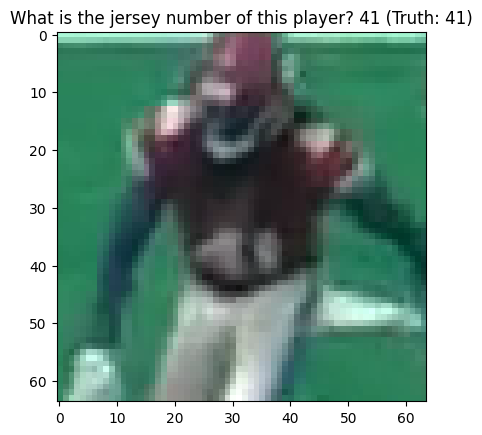

In [84]:
# viz example prediction
example = test_dataset[85]
output = generate_text_from_sample(model, processor, example)
plt.imshow(example["messages"][1]["content"][0]['image'])
plt.title(f"{example["messages"][1]["content"][1]["text"]} {output} (Truth: {example["messages"][2]["content"][0]['text']})")
plt.show()
